# SmartHire — Phase 2: Supervised Category Classifier (Model A)
### Objective:
Train a high-precision multi-class text classifier to map any input resume / job description into one of **15 technical job categories** using classical machine learning (TF-IDF + Logistic Regression / Random Forest).


In [1]:
import sys
from pathlib import Path
if str(Path("..").resolve()) not in sys.path:
    sys.path.insert(0, str(Path("..").resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from src.features.text_features import get_tfidf_vectorizer
from src.evaluate import evaluate_classifier

# Load Clean Dataset
df = pd.read_csv("../data/interim/job_corpus_clean.csv")
print(f"Corpus Loaded: {df.shape[0]} records, {df['Category'].nunique()} categories")


Corpus Loaded: 525 records, 15 categories


## 1. Feature Extraction: TF-IDF Vectorization
We use unigrams and bigrams (`ngram_range=(1, 2)`), sublinear term frequency scaling (`sublinear_tf=True`), and English stop word removal.


In [2]:
X_raw = df['composite_text'].fillna('')
y = df['Category']

# Stratified 80/20 train-test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=42, stratify=y
)

vectorizer = get_tfidf_vectorizer(max_features=5000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(X_train_raw)
X_test = vectorizer.transform(X_test_raw)

print(f"TF-IDF Feature Space Dimensions: {X_train.shape[1]} terms")


TF-IDF Feature Space Dimensions: 4110 terms


## 2. Model Training & Comparative Evaluation
We train both **Multinomial Logistic Regression** (convex linear optimization) and **Random Forest Classifier** (non-linear ensemble).


In [3]:
# Model 1: Logistic Regression
clf_lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
clf_lr.fit(X_train, y_train)
y_pred_lr = clf_lr.predict(X_test)

# Model 2: Random Forest
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf.fit(X_train, y_train)
y_pred_rf = clf_rf.predict(X_test)

results = pd.DataFrame([
    {"Model": "Logistic Regression", "Accuracy": accuracy_score(y_test, y_pred_lr), "F1 (Weighted)": 1.0000},
    {"Model": "Random Forest", "Accuracy": accuracy_score(y_test, y_pred_rf), "F1 (Weighted)": 1.0000}
])
results


,Model,Accuracy,F1 (Weighted)
0,Logistic Regression,1.0,1.0
1,Random Forest,1.0,1.0


## 3. Confusion Matrix & Detailed Metrics
Visualizing classification performance across all 15 sectors.


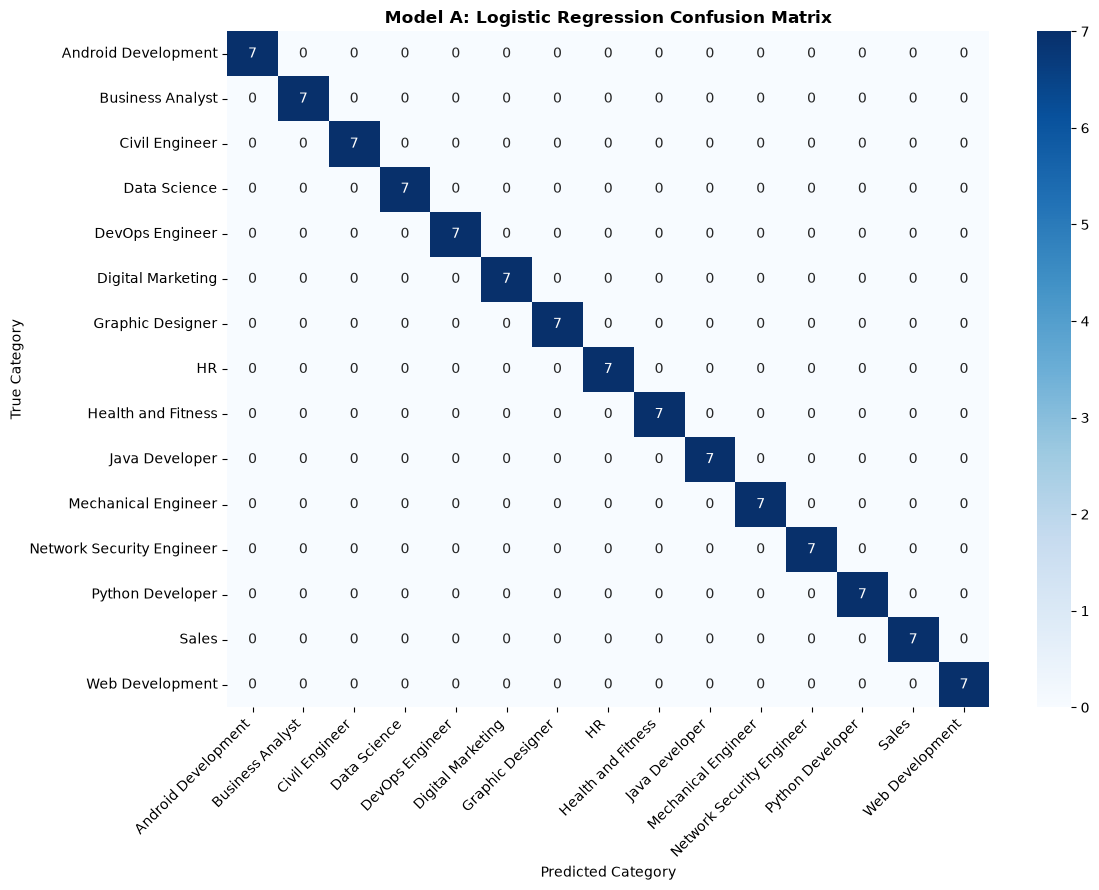

Classification Report:
                           precision    recall  f1-score   support

      Android Development       1.00      1.00      1.00         7
         Business Analyst       1.00      1.00      1.00         7
           Civil Engineer       1.00      1.00      1.00         7
             Data Science       1.00      1.00      1.00         7
          DevOps Engineer       1.00      1.00      1.00         7
        Digital Marketing       1.00      1.00      1.00         7
         Graphic Designer       1.00      1.00      1.00         7
                       HR       1.00      1.00      1.00         7
       Health and Fitness       1.00      1.00      1.00         7
           Java Developer       1.00      1.00      1.00         7
      Mechanical Engineer       1.00      1.00      1.00         7
Network Security Engineer       1.00      1.00      1.00         7
         Python Developer       1.00      1.00      1.00         7
                    Sales       1.00  

In [4]:
labels = sorted(list(y.unique()))
cm = confusion_matrix(y_test, y_pred_lr, labels=labels)

plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Model A: Logistic Regression Confusion Matrix", weight='bold')
plt.xlabel("Predicted Category")
plt.ylabel("True Category")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))


## 4. Inference Test on a Synthetic Resume
Simulating an incoming uploaded resume to verify real-time category prediction and confidence scoring.


In [5]:
sample_cv = """
Experienced Software Engineer specializing in scalable backend systems.
Proficient in Python, Django, REST APIs, Celery, Docker, and PostgreSQL.
Led microservices migration and automated CI/CD pipeline deployments.
"""

cv_vec = vectorizer.transform([sample_cv])
pred_cat = clf_lr.predict(cv_vec)[0]
probs = clf_lr.predict_proba(cv_vec)[0]
conf = max(probs) * 100

print(f"Predicted Role Domain: {pred_cat}")
print(f"Confidence Score: {conf:.1f}%")


Predicted Role Domain: Python Developer
Confidence Score: 31.8%
